In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Create House Prices Dataset
np.random.seed(42)
n = 200
data = {
    'area':        np.random.randint(500, 4000, n),
    'bedrooms':    np.random.randint(1, 6, n),
    'bathrooms':   np.random.randint(1, 4, n),
    'age':         np.random.randint(1, 50, n),
    'garage':      np.random.randint(0, 3, n),
}
price = (data['area']*150 + data['bedrooms']*10000 +
         data['bathrooms']*8000 - data['age']*500 +
         data['garage']*5000 +
         np.random.normal(0, 15000, n) + 50000).astype(int)
data['price'] = np.clip(price, 80000, 800000)
df = pd.DataFrame(data)

print("✅ Dataset Ready!")
print("Shape:", df.shape)
df.head()

✅ Dataset Ready!
Shape: (200, 6)


,area,bedrooms,bathrooms,age,garage,price
0,3674,4,2,23,0,636948
1,1360,4,3,16,1,326330
2,1794,3,3,39,1,366113
3,1630,2,2,45,2,303336
4,1595,4,3,42,0,333739


=== Dataset Info ===
              area    bedrooms   bathrooms         age      garage  \
count   200.000000  200.000000  200.000000  200.000000  200.000000   
mean   2333.775000    2.780000    1.895000   24.580000    1.060000   
std     992.421831    1.393308    0.816891   14.456088    0.806008   
min     521.000000    1.000000    1.000000    1.000000    0.000000   
25%    1519.000000    1.000000    1.000000   12.000000    0.000000   
50%    2372.000000    3.000000    2.000000   25.000000    1.000000   
75%    3229.500000    4.000000    3.000000   37.000000    2.000000   
max    3999.000000    5.000000    3.000000   49.000000    2.000000   

               price  
count     200.000000  
mean   435338.405000  
std    149907.654237  
min    127758.000000  
25%    307202.000000  
50%    443445.500000  
75%    570680.250000  
max    683650.000000  

Missing Values: 0


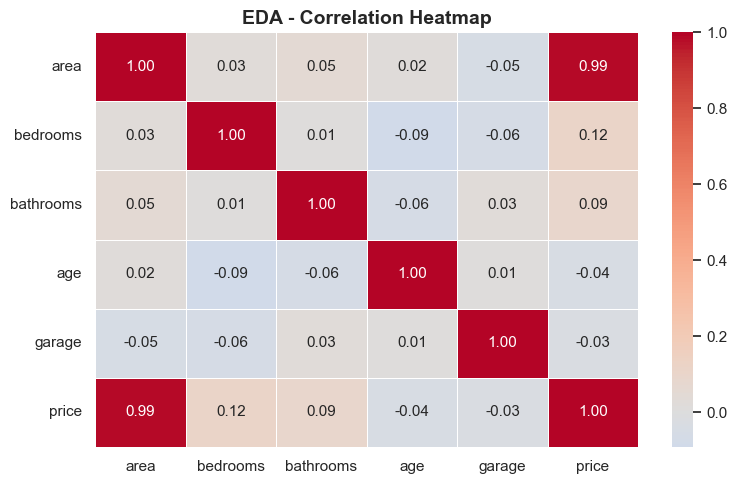

In [2]:
print("=== Dataset Info ===")
print(df.describe())
print("\nMissing Values:", df.isnull().sum().sum())

# Correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size':11})
plt.title('EDA - Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [3]:
# All features for Multiple Regression
X_multi = df[['area','bedrooms','bathrooms','age','garage']]
y = df['price']

# Single feature for Simple Regression
X_simple = df[['area']]

print("✅ Features and Target Split Done!")
print("X (Multiple) shape:", X_multi.shape)
print("X (Simple)   shape:", X_simple.shape)
print("y (Target)   shape:", y.shape)

✅ Features and Target Split Done!
X (Multiple) shape: (200, 5)
X (Simple)   shape: (200, 1)
y (Target)   shape: (200,)


In [4]:
# Simple Regression split
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42)

# Multiple Regression split
X_train_m, X_test_m, _, _ = train_test_split(
    X_multi, y, test_size=0.2, random_state=42)

print("✅ Train-Test Split Done!")
print(f"Training samples : {X_train_s.shape[0]}")
print(f"Testing  samples : {X_test_s.shape[0]}")

✅ Train-Test Split Done!
Training samples : 160
Testing  samples : 40


In [5]:
# Train Simple Linear Regression (only area → price)
simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train)

print("✅ Simple Linear Regression Trained!")
print(f"Intercept    : {simple_model.intercept_:,.2f}")
print(f"Coefficient  : {simple_model.coef_[0]:,.2f}")
print(f"\nMeaning: Price = {simple_model.coef_[0]:,.0f} x Area + {simple_model.intercept_:,.0f}")

✅ Simple Linear Regression Trained!
Intercept    : 85,168.60
Coefficient  : 149.93

Meaning: Price = 150 x Area + 85,169


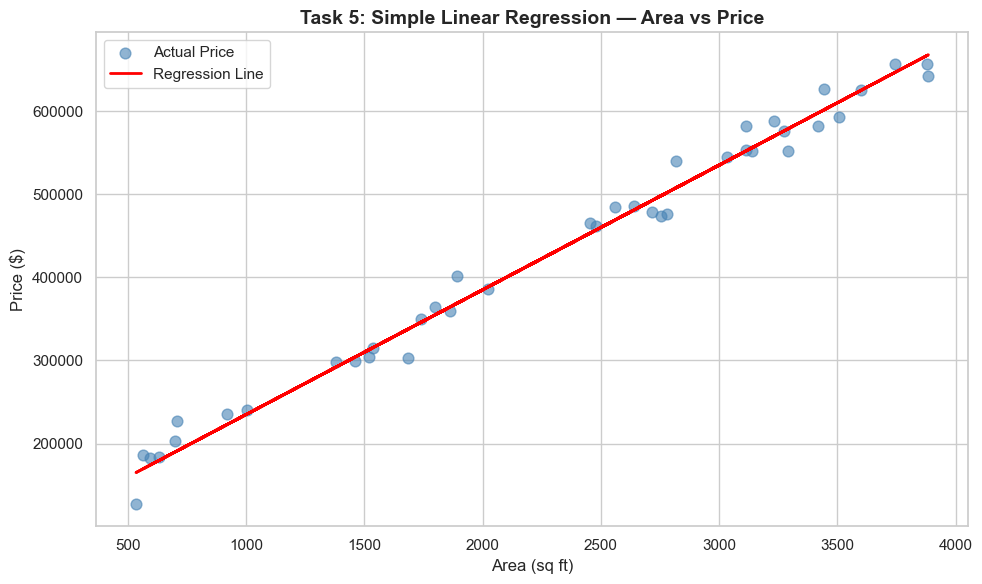

In [6]:
y_pred_simple = simple_model.predict(X_test_s)

plt.figure(figsize=(10, 6))
plt.scatter(X_test_s, y_test, color='steelblue',
            alpha=0.6, s=60, label='Actual Price')
plt.plot(X_test_s, y_pred_simple, color='red',
         linewidth=2, label='Regression Line')
plt.xlabel('Area (sq ft)', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.title('Task 5: Simple Linear Regression — Area vs Price',
          fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# Train Multiple Linear Regression (all features)
multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train)

print("✅ Multiple Linear Regression Trained!")
print("\nCoefficients:")
for feature, coef in zip(X_multi.columns, multi_model.coef_):
    print(f"  {feature:12} : {coef:,.2f}")
print(f"\n  Intercept    : {multi_model.intercept_:,.2f}")

✅ Multiple Linear Regression Trained!

Coefficients:
  area         : 149.88
  bedrooms     : 9,802.33
  bathrooms    : 6,594.90
  age          : -452.66
  garage       : 5,000.96

  Intercept    : 51,449.37


In [8]:
# Predictions
y_pred_simple = simple_model.predict(X_test_s)
y_pred_multi  = multi_model.predict(X_test_m)

print("✅ Predictions Done!")
print("\nSample Predictions (Multiple Regression):")
print(f"{'Actual':>12} {'Predicted':>12} {'Difference':>12}")
print("-" * 38)
for actual, predicted in zip(list(y_test[:5]), y_pred_multi[:5]):
    diff = actual - predicted
    print(f"${actual:>11,} ${predicted:>11,.0f} ${diff:>11,.0f}")

✅ Predictions Done!

Sample Predictions (Multiple Regression):
      Actual    Predicted   Difference
--------------------------------------
$    540,490 $    515,819 $     24,671
$    581,785 $    595,229 $    -13,444
$    642,175 $    675,879 $    -33,704
$    240,659 $    246,398 $     -5,739
$    235,306 $    238,965 $     -3,659


In [9]:
# Simple Regression metrics
mse_simple = mean_squared_error(y_test, y_pred_simple)
r2_simple  = r2_score(y_test, y_pred_simple)

# Multiple Regression metrics
mse_multi = mean_squared_error(y_test, y_pred_multi)
r2_multi  = r2_score(y_test, y_pred_multi)

print("=" * 50)
print("       MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"\n📊 SIMPLE LINEAR REGRESSION (area only)")
print(f"   MSE       : {mse_simple:,.2f}")
print(f"   RMSE      : {np.sqrt(mse_simple):,.2f}")
print(f"   R-squared : {r2_simple:.4f} ({r2_simple*100:.1f}%)")

print(f"\n📊 MULTIPLE LINEAR REGRESSION (all features)")
print(f"   MSE       : {mse_multi:,.2f}")
print(f"   RMSE      : {np.sqrt(mse_multi):,.2f}")
print(f"   R-squared : {r2_multi:.4f} ({r2_multi*100:.1f}%)")

print("\n" + "=" * 50)
better = "Multiple" if r2_multi > r2_simple else "Simple"
print(f"✅ {better} Regression performs better!")
print("=" * 50)

       MODEL EVALUATION RESULTS

📊 SIMPLE LINEAR REGRESSION (area only)
   MSE       : 324,429,225.94
   RMSE      : 18,011.92
   R-squared : 0.9865 (98.7%)

📊 MULTIPLE LINEAR REGRESSION (all features)
   MSE       : 231,923,880.70
   RMSE      : 15,229.05
   R-squared : 0.9904 (99.0%)

✅ Multiple Regression performs better!


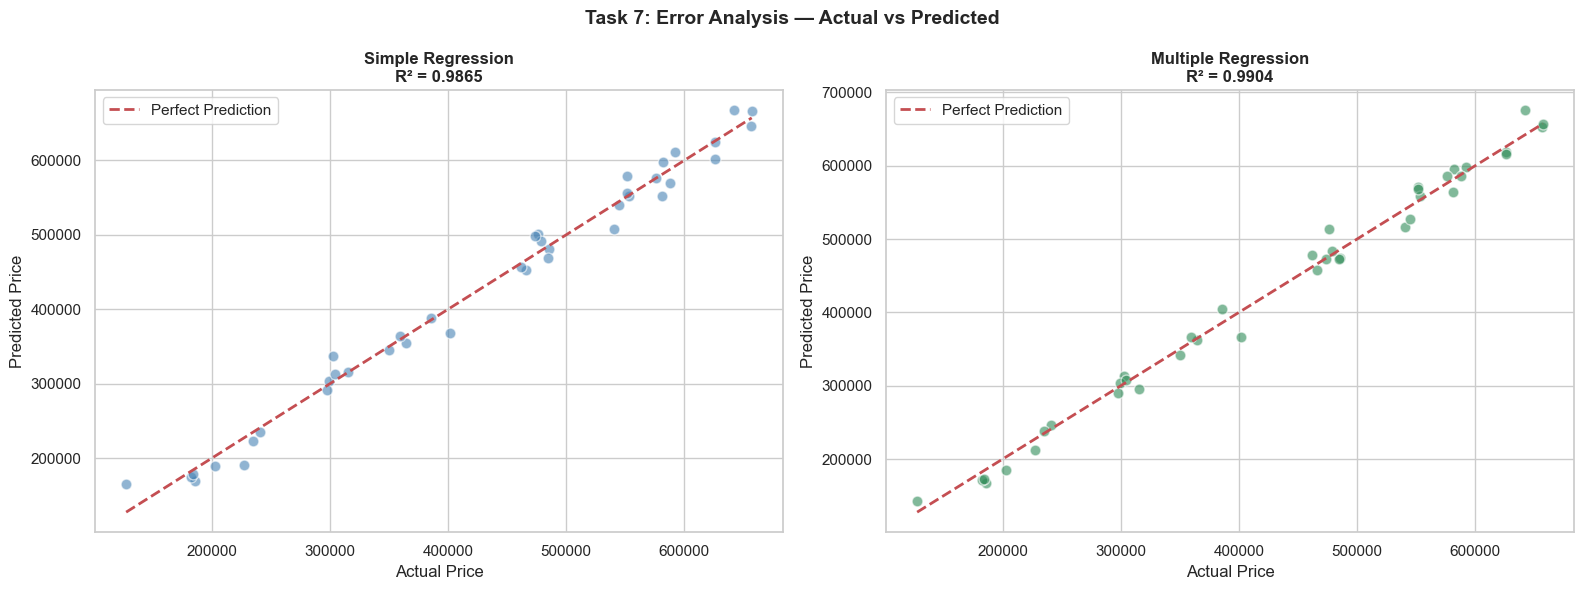

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Simple Regression errors
axes[0].scatter(y_test, y_pred_simple, alpha=0.6,
                color='steelblue', edgecolors='white', s=60)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Simple Regression\nR² = {r2_simple:.4f}',
                  fontweight='bold')
axes[0].legend()

# Multiple Regression errors
axes[1].scatter(y_test, y_pred_multi, alpha=0.6,
                color='seagreen', edgecolors='white', s=60)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].set_title(f'Multiple Regression\nR² = {r2_multi:.4f}',
                  fontweight='bold')
axes[1].legend()

plt.suptitle('Task 7: Error Analysis — Actual vs Predicted',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

 
INTERVIEW QUESTIONS — ANSWERS
══════════════════════════════════════════════════════════

Q1. Assumptions of Linear Regression?
    1. Linear relationship between X and y
    2. No multicollinearity between features
    3. Residuals are normally distributed
    4. Homoscedasticity (equal variance of errors)
    5. No autocorrelation in residuals

Q2. R-squared vs Adjusted R-squared?
    R-squared        = How much variance is explained by model
                       Always increases when features are added
    Adjusted R-squared = Penalizes for adding useless features
                       Better for Multiple Regression evaluation

Q3. Cost Function in Linear Regression?
    Mean Squared Error (MSE)
    Formula: MSE = (1/n) * Σ(actual - predicted)²
    Goal: Minimize this using Gradient Descent

Q4. Significance of Intercept and Coefficients?
    Intercept    = Value of y when all X = 0 (base price)
    Coefficients = How much y changes for 1 unit change in X
    Example: coef of area = 150 means every 1 sqft
             increases price by $150

Q5. How to handle Multicollinearity?
    1. Remove highly correlated features
    2. Use PCA (Principal Component Analysis)
    3. Use Ridge or Lasso Regression
    4. Check VIF (Variance Inflation Factor)
       VIF > 10 means high multicollinearity

══════════════════════════════════════════════════════════
